In [2]:
!pip install model2vec[distill] sentence-transformers transformers tf-keras datasets umap-learn plotly

In [3]:
from warnings import filterwarnings
filterwarnings('ignore')

import os
import json
import re
import multiprocessing
import torch

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
from datasets import load_dataset, load_from_disk, DatasetDict
from transformers import (AutoTokenizer, AutoModel, AutoModelForMaskedLM, AutoConfig, DataCollatorForLanguageModeling, Trainer, TrainingArguments, EarlyStoppingCallback)

from model2vec import StaticModel
from model2vec.distill import distill

from scipy.spatial.distance import cosine
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

Download the data from [this link]('https://console.cloud.google.com/storage/browser/deepmind-gutenberg') or load it from HuggingFace datasets

In [4]:
save_dir = Path("data/pg19")
save_dir.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")
    ds.save_to_disk(save_dir) 

Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

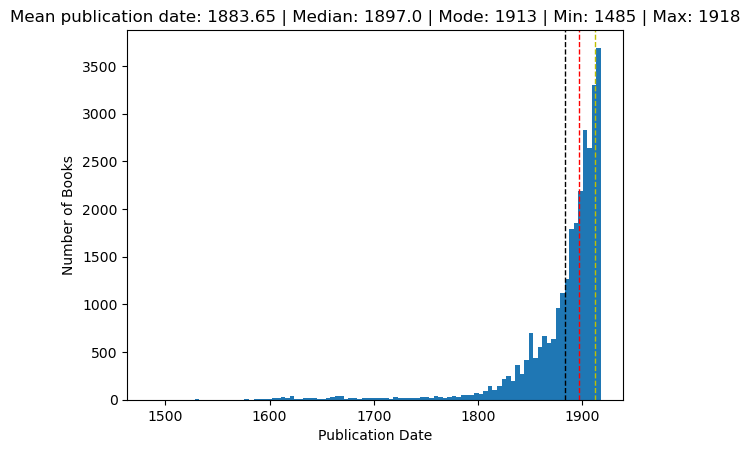

In [5]:
plt.hist(ds['train']['publication_date'], bins=100)
mu = np.mean(ds['train']['publication_date'])
median = np.median(ds['train']['publication_date'])
mode = np.bincount(ds['train']['publication_date']).argmax()
_min, _max = np.min(ds['train']['publication_date']), np.max(ds['train']['publication_date'])
plt.axvline(mu, color='k', linestyle='dashed', linewidth=1)
plt.axvline(median, color='r', linestyle='dashed', linewidth=1)
plt.axvline(mode, color='y', linestyle='dashed', linewidth=1)
plt.title(f"Mean publication date: {mu:.2f} | Median: {median} | Mode: {mode} | Min: {_min} | Max: {_max}")
plt.xlabel("Publication Date")
plt.ylabel("Number of Books")
plt.show()

In [6]:
out = Path("data/pg19/corpus.txt")
out.parent.mkdir(parents=True, exist_ok=True)
if not out.exists():
    fields = ds['train'].column_names
    for f in ('text','content','raw_text','body','book_text'):
        if f in fields:
            corpus = "\n\n".join(ds['train'][f])
            break
    else:
        raise RuntimeError(f"No text field found in {fields}")
    out.write_text(corpus)
    print("Wrote", out, "bytes:", out.stat().st_size)

In [7]:
# 1. Setup - Use all available CPU cores
num_proc = multiprocessing.cpu_count()
print(f"Using {num_proc} CPU cores for processing.")

# 2. Load Data
save_dir = Path("data/pg19")
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")

if isinstance(ds, DatasetDict):
    ds = ds['train']

# Select subset (500 books)
ds = ds.select(range(500)) 

# 3. Load Fast Tokenizer
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# 4. The "Pack and Slice" Strategy
block_size = 128

def group_texts(examples):
    # a. Tokenize ONLY the text column
    tokenized_inputs = tokenizer(
        examples["text"], 
        return_special_tokens_mask=True,
        truncation=False, 
        add_special_tokens=False
    )
    
    # b. Concatenate all token lists into one huge list
    concatenated_examples = {k: sum(tokenized_inputs[k], []) for k in tokenized_inputs.keys()}
    
    # c. Compute total length safely using 'input_ids'
    total_length = len(concatenated_examples["input_ids"])
    
    # d. Drop remainder
    total_length = (total_length // block_size) * block_size
    
    # e. Split into chunks
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    
    return result

print("Tokenizing and Packing...")

# IMPORTANT: We explicitly define which columns to remove BEFORE mapping
# so they don't mess up the multiprocessing
cols_to_remove = ds.column_names

lm_dataset = ds.map(
    group_texts,
    batched=True,
    batch_size=100,      # Reduced batch size to safely fit RAM during concat
    num_proc=num_proc,   
    remove_columns=cols_to_remove # Clean out old columns (titles, urls, etc)
)

print(f"Done! Generated {len(lm_dataset)} training samples.")

# 5. Save to Disk
lm_dataset.save_to_disk("data/pg19_processed_tokens")
print("Saved processed dataset to 'data/pg19_processed_tokens'")

Using 40 CPU cores for processing.


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Tokenizing and Packing...
Done! Generated 373700 training samples.


Saving the dataset (0/1 shards):   0%|          | 0/373700 [00:00<?, ? examples/s]

Saved processed dataset to 'data/pg19_processed_tokens'


In [8]:
def ensure_transformer_saved(model_id, output_path):
    out = Path(output_path)
    if out.exists():
        print(f"Model already at {output_path}")
        return
    model = AutoModel.from_pretrained(model_id)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model.save_pretrained(output_path)
    tokenizer.save_pretrained(output_path)
    print(f"Saved model to {output_path}")

ensure_transformer_saved("sentence-transformers/all-MiniLM-L6-v2", "models/all-MiniLM-L6-v2")

Model already at models/all-MiniLM-L6-v2


In [9]:
def ensure_teacher_finetuned(output_dir, base_model="sentence-transformers/all-MiniLM-L6-v2"):
    out = Path(output_dir)
    if out.exists():
        print(f"Teacher exists at {output_dir}")
        return
    dataset = load_from_disk("data/pg19_processed_tokens")
    ds_size = len(dataset)
    train_dataset = dataset.shuffle(seed=42).select(range(int(ds_size * 0.85)))
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    model = AutoModelForMaskedLM.from_pretrained(base_model)
    args = TrainingArguments(output_dir=output_dir, per_device_train_batch_size=64, num_train_epochs=1, learning_rate=1e-5, fp16=True, save_strategy="no", logging_steps=100)
    trainer = Trainer(model=model, args=args, train_dataset=train_dataset, data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15))
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Saved teacher to {output_dir}")

ensure_teacher_finetuned("models/pg19_tuned_teacher")

Teacher exists at models/pg19_tuned_teacher


In [10]:
def ensure_scratch_teacher(output_dir, base_model="sentence-transformers/all-MiniLM-L6-v2"):
    out = Path(output_dir)
    if out.exists():
        print(f"Scratch teacher exists at {output_dir}")
        return
    dataset = load_from_disk("data/pg19_processed_tokens")
    full_split = dataset.shuffle(seed=42).train_test_split(test_size=0.10)
    train_dataset = full_split['train']
    eval_dataset = full_split['test']
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    config = AutoConfig.from_pretrained(base_model)
    model = AutoModelForMaskedLM.from_config(config)
    args = TrainingArguments(output_dir=output_dir, per_device_train_batch_size=64, per_device_eval_batch_size=64, num_train_epochs=10, learning_rate=1e-4, warmup_steps=500, fp16=True, eval_strategy="steps", eval_steps=200, save_strategy="steps", save_steps=200, load_best_model_at_end=True, metric_for_best_model="loss", greater_is_better=False, save_total_limit=2, logging_steps=50)
    trainer = Trainer(model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset, data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15), callbacks=[EarlyStoppingCallback(early_stopping_patience=3)])
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Saved scratch teacher to {output_dir}")

ensure_scratch_teacher("models/pg19_scratch_teacher_best")

Scratch teacher exists at models/pg19_scratch_teacher_best


In [11]:
def ensure_aggressive_tuning(output_dir, base_model="sentence-transformers/all-MiniLM-L6-v2"):
    out = Path(output_dir)
    if out.exists():
        print(f"Aggressive tuned model exists at {output_dir}")
        return
    dataset = load_from_disk("data/pg19_processed_tokens")
    tokenizer = AutoTokenizer.from_pretrained(base_model)
    model = AutoModelForMaskedLM.from_pretrained(base_model)
    args = TrainingArguments(output_dir=output_dir, per_device_train_batch_size=64, num_train_epochs=3, learning_rate=6e-5, fp16=True, save_strategy="no", logging_steps=400)
    trainer = Trainer(model=model, args=args, train_dataset=dataset.shuffle(seed=42).select(range(min(len(dataset), 5000))), data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15))
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Saved aggressive model to {output_dir}")

ensure_aggressive_tuning("models/pg19_aggressive_tuning")

Aggressive tuned model exists at models/pg19_aggressive_tuning


In [12]:
def ensure_distilled(teacher_path, save_path):
    out = Path(save_path)
    if out.exists():
        print(f"Static model already at {save_path}")
        return
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Distilling from {teacher_path} on {device}...")
    pg19_static = distill(model_name=teacher_path, device=device)
    pg19_static.save_pretrained(save_path)
    print(f"Saved static to {save_path}")

ensure_distilled("models/pg19_tuned_teacher", "models/pg19_static_final")
ensure_distilled("models/pg19_scratch_teacher_best", "models/pg19_scratch_static_final")
ensure_distilled("models/pg19_aggressive_tuning", "models/pg19_aggressive_static_final")
ensure_distilled("models/all-MiniLM-L6-v2", "models/all-MiniLM-L6-v2_static")

Static model already at models/pg19_static_final
Static model already at models/pg19_scratch_static_final
Static model already at models/pg19_aggressive_static_final
Static model already at models/all-MiniLM-L6-v2_static


In [13]:
model_modern = StaticModel.from_pretrained("minishlab/potion-base-8m") # Modern Baseline
model_modern = StaticModel.from_pretrained("models/all-MiniLM-L6-v2_static")   # pre-trained from scratch
model_pg19 = StaticModel.from_pretrained("models/pg19_static_final")   # Your 19th Century Model (fine-tuned)
model_pg19 = StaticModel.from_pretrained("models/pg19_scratch_static_final")   # pre-trained from scratch
model_pg19 = StaticModel.from_pretrained("models/pg19_aggressive_static_final")   # pre-trained from scratch

# Define the Probe
word = "cloud"
anchor = "sky"

# 1. Modern Distance
vec_mod_word = model_modern.encode([word])[0]
vec_mod_anchor = model_modern.encode([anchor])[0]
dist_mod = cosine(vec_mod_word, vec_mod_anchor)

# 2. PG-19 Distance
vec_old_word = model_pg19.encode([word])[0]
vec_old_anchor = model_pg19.encode([anchor])[0]
dist_old = cosine(vec_old_word, vec_old_anchor)

print(f"Distance '{word}' <-> '{anchor}'")
print(f"Modern Model: {dist_mod:.4f} (Should be far, > 0.6)")
print(f"PG-19 Model:  {dist_old:.4f} (Should be closer, < 0.5)")

diff = dist_mod - dist_old
if diff > 0:
    print(f"\nSUCCESS: The word {word} moved {diff:.4f} closer to {anchor}!")
else:
    print("\nWARNING: No significant drift detected. You might need to train for more epochs.")

Distance 'cloud' <-> 'sky'
Modern Model: 0.6397 (Should be far, > 0.6)
PG-19 Model:  0.4021 (Should be closer, < 0.5)

SUCCESS: The word cloud moved 0.2376 closer to sky!


In [14]:
def sanity_check(model, name):
    print(f"--- Sanity Check: {name} ---")
    # 1. Check Synonyms (Should be close, Dist < 0.5)
    d1 = cosine(model.encode(["good"])[0], model.encode(["great"])[0])
    print(f"Distance 'good' <-> 'great': {d1:.4f} {'✅' if d1 < 0.6 else '❌ BROKEN'}")

    # 2. Check Unrelated (Should be far, Dist ~ 1.0)
    d2 = cosine(model.encode(["apple"])[0], model.encode(["car"])[0])
    print(f"Distance 'apple' <-> 'car':   {d2:.4f} {'✅' if d2 > 0.7 else '❌ BROKEN'}")
    print("")

# Run on your scratch model
sanity_check(model_pg19, "PG-19 From Scratch")

--- Sanity Check: PG-19 From Scratch ---
Distance 'good' <-> 'great': 0.4089 ✅
Distance 'apple' <-> 'car':   0.9600 ✅





**Orthogonal Procrustes Problem**

Given a source embedding matrix $A$ and a target embedding matrix $B$, we seek the optimal orthogonal rotation matrix $R$:

\begin{equation}
    R = \operatorname*{argmin}_{\Omega \in \mathbb{R}^{d \times d}} \| A\Omega - B \|_F^2 \quad \text{subject to} \quad \Omega^T\Omega = I
\end{equation}

**Solution via SVD**
The optimal rotation is obtained using the Singular Value Decomposition (SVD):

\begin{align}
    M &= B^T A \\
    U, \Sigma, V^T &= \operatorname{SVD}(M) \\
    R &= U V^T
\end{align}


In [15]:
import os
import json
import re
from collections import Counter
from tqdm import tqdm

dataset = load_from_disk("data/pg19_processed_tokens")
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
ds_size = len(dataset)

def compute_and_store_word_counts(dataset, tokenizer, save_path="data/pg19_word_counts.json", batch_size=1000, overwrite=False):
    """
    Compute word counts over a HuggingFace `dataset` decoding with `tokenizer` in batches.
    If `save_path` exists and `overwrite` is False, loads and returns the saved counts.
    Returns a `collections.Counter` of word -> count.
    """
    if os.path.exists(save_path) and not overwrite:
        with open(save_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return Counter({k: int(v) for k, v in data.items()})

    cnt = Counter()
    ds_size = len(dataset)
    for i in tqdm(range(0, ds_size, batch_size), desc="Counting words"):
        batch = dataset[i: i + batch_size]
        # adjust field name if your dataset uses something else
        batch_ids = batch["input_ids"]
        texts = tokenizer.batch_decode(batch_ids, skip_special_tokens=True)
        for t in texts:
            words = re.findall(r"\b\w+\b", t.lower())
            cnt.update(words)

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump({k: int(v) for k, v in cnt.items()}, f, ensure_ascii=False)
    return cnt

def most_common_(word_counts, n=100, exclude=None, include=None):
    """
    Return top-n most common words not in `exclude` (case-insensitive).
    `word_counts` can be a Counter or a dict-like mapping.
    Optionally, specific words can be forced to be included via `include` list.
    """
    if include:
        include_set = set(w.lower() for w in include)
    exclude_set = set(w.lower() for w in (exclude or []))
    if not isinstance(word_counts, Counter):
        word_counts = Counter(word_counts)
    results = []
    for w, c in word_counts.most_common():
        if w in exclude_set:
            continue
        results.append((w, c))
        if len(results) >= n:
            break
    return results

def most_common(word_counts, n=100, exclude=None, include=None):
    """
    Return top-n most common words, forcing include words into the result.
    - word_counts can be a Counter or a dict-like mapping.
    - exclude is a list/set of words to omit unless they are in include.
    - include is an ordered list of words that must appear (in that order) if provided.
    Results are lower-cased.
    """
    exclude_set = set(w.lower() for w in (exclude or []))
    include_list = [w.lower() for w in (include or [])]
    include_set = set(include_list)
    exclude_set = exclude_set - include_set
    # normalize
    if not isinstance(word_counts, Counter):
        word_counts = Counter({k.lower(): int(v) for k, v in word_counts.items()})
    else:
        word_counts = Counter({k.lower(): int(v) for k, v in word_counts.items()})
    results = []
    added = set()
    for w in include_list:
        if w in added:
            continue
        c = word_counts.get(w, 0)
        results.append((w, c))
        added.add(w)
        if len(results) >= n:
            return results[:n]
    for w, c in word_counts.most_common():
        if w in exclude_set or w in added:
            continue
        results.append((w, c))
        added.add(w)
        if len(results) >= n:
            break
    return results[:n]

STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Abstract/Grammar (High Frequency)
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]

wc = compute_and_store_word_counts(dataset, tokenizer, save_path="data/pg19_word_counts.json", batch_size=2000)

probes = ["cloud", "gay", "mouse", "intercourse", "cool"] 

stops = {"the","and","of","to","a","in","is","it","that","for","on","with","as","are"}
stops = set()
TOP_ANCHORS = most_common_(wc, n=1_000, exclude=stops.union(probes), include=STABLE_ANCHORS)
TOP_ANCHORS[:10]

[('the', 2285168),
 ('of', 1274161),
 ('and', 1215820),
 ('to', 957956),
 ('a', 741321),
 ('in', 644620),
 ('that', 446596),
 ('i', 444187),
 ('he', 392113),
 ('it', 371515)]

In [16]:
def get_suitable_drift_words(word_counts, probes, min_count=50, min_selected=5, print_verdict=False):
    """
    Determine a subset of probes suitable for drift analysis based on occurrence counts.
    Args:
        word_counts: Counter or dict mapping word -> count (case-insensitive counts preferred).
        probes: iterable of probe word strings.
        print_verdict: if True, prints a small table of probe -> count -> verdict.
        min_count: initial minimum absolute count threshold for a probe to be considered 'Good'.
        min_selected: try to select at least this many probes by relaxing threshold if needed.

    Returns:
        List of selected probe words (lowercased) ordered by their count descending.
    """
    # Normalize word_counts to lowercase Counter
    if not isinstance(word_counts, Counter):
        wc = Counter({k.lower(): int(v) for k, v in word_counts.items()})
    else:
        wc = Counter({k.lower(): int(v) for k, v in word_counts.items()})

    probes_norm = [p.lower() for p in probes]
    # Try thresholds, relaxing until we have at least min_selected or threshold reaches 1
    threshold = max(1, int(min_count))
    selected = []
    while True:
        selected = [(p, wc.get(p, 0)) for p in probes_norm if wc.get(p, 0) >= threshold]
        # sort by count desc
        selected.sort(key=lambda x: x[1], reverse=True)
        if len(selected) >= min_selected or threshold <= 1:
            break
        # Relax: halve threshold but at least 1
        threshold = max(1, threshold // 2)

    if print_verdict:
        header = f"{'WORD':<20} | {'COUNT':<10} | {'VERDICT'}"
        print(header)
        print("-" * len(header))
        for p in probes_norm:
            c = wc.get(p, 0)
            verdict = "✅ Good" if any(p == s for s, _ in selected) else "❌ Too Rare"
            print(f"{p:<20} | {c:<10} | {verdict}")

    # return only the words (in original probe order filtered by presence in selected set),
    # but ordered by descending count to prefer higher-frequency probes.
    selected_words = list(set([w for w, _ in selected]))
    return selected_words

probes = ["broadcast", "monitor", "mouse", "intercourse", 
          "toilet", "traffic", "gay", "consumption",
          "cloud", "web", "cloud", "bug", "troll", "bullet", "like",
          "viral", "spam", "ghost", "qeer", 
          ]

DRIFT_WORDS = get_suitable_drift_words(wc, probes, min_count=100, min_selected=5, print_verdict=True)

WORD                 | COUNT      | VERDICT
-------------------------------------------
broadcast            | 40         | ❌ Too Rare
monitor              | 94         | ❌ Too Rare
mouse                | 469        | ✅ Good
intercourse          | 971        | ✅ Good
toilet               | 158        | ✅ Good
traffic              | 562        | ✅ Good
gay                  | 1796       | ✅ Good
consumption          | 381        | ✅ Good
cloud                | 1827       | ✅ Good
web                  | 238        | ✅ Good
cloud                | 1827       | ✅ Good
bug                  | 117        | ✅ Good
troll                | 32         | ❌ Too Rare
bullet               | 519        | ✅ Good
like                 | 50947      | ✅ Good
viral                | 0          | ❌ Too Rare
spam                 | 0          | ❌ Too Rare
ghost                | 1135       | ✅ Good
qeer                 | 0          | ❌ Too Rare


Loading models...
Common vocabulary size: 4301
Procrustes residual (anchors): 4.10e-01

Top drifting words:
name: 0.6951
post: 0.6801
used: 0.6725
باد: 0.6633
works: 0.6609
the: 0.6064
link: 0.6039
use: 0.5998
point: 0.5962
typical: 0.5930
its: 0.5900
utter: 0.5852
note: 0.5796
pic: 0.5761
tag: 0.5743


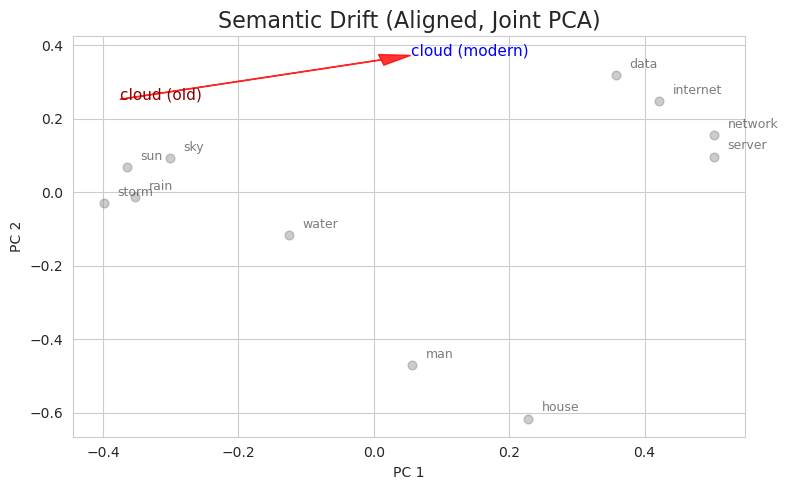

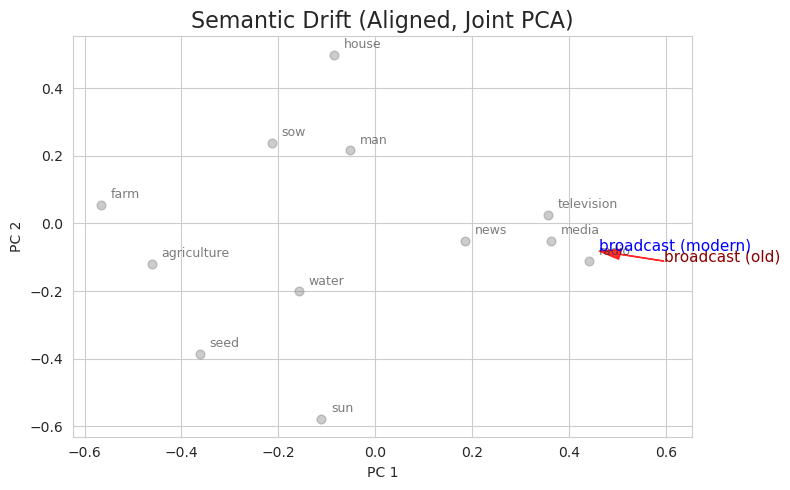

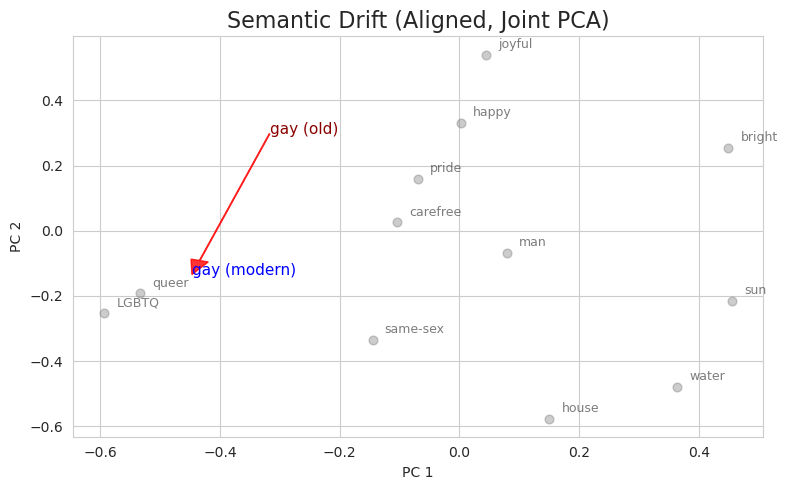

Loading models...
Common vocabulary size: 4301
Procrustes residual (anchors): 1.33e-15


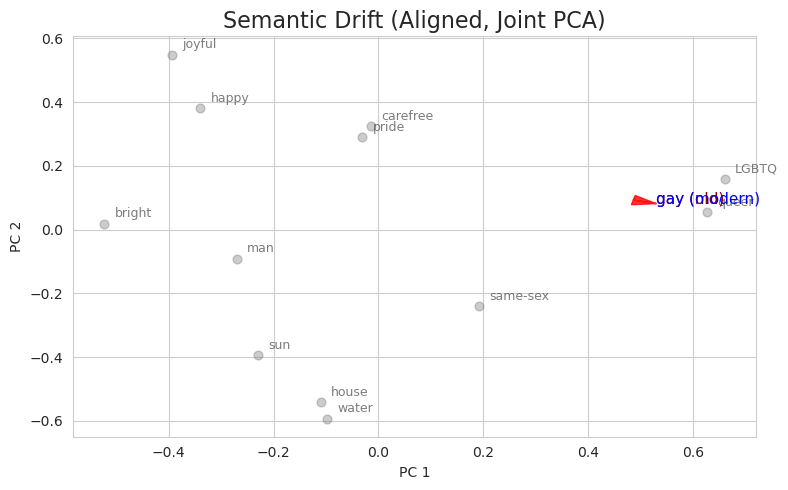

In [17]:
def pprint(*args, verbose=True):
    if verbose:
        print(*args)


MODERN_PATH = "minishlab/potion-base-8m" # Or your distilled modern base
MODERN_PATH = "models/all-MiniLM-L6-v2_static" # Or your distilled modern base
PG19_PATH = "models/pg19_static_final"   # Your trained model
PG19_PATH = "models/pg19_scratch_static_final"   # Your trained model
PG19_PATH = "models/pg19_aggressive_static_final"   # Your trained model

IGNORE_LIST = set(
   # ["the", "of", "and", "to", "a", "in", "is", "it", "that", "i", "unused"]
) # include stopwords for now


def load_and_align_models(path1, path2, ignore_list, verbose=True):
    pprint("Loading models...", verbose=verbose)
    mod_modern = StaticModel.from_pretrained(path1)
    mod_pg19 = StaticModel.from_pretrained(path2)

    vocab_modern = set(mod_modern.tokenizer.get_vocab().keys())
    vocab_pg19 = set(mod_pg19.tokenizer.get_vocab().keys())

    common_vocab = sorted(vocab_modern & vocab_pg19)
    common_vocab = [
        w for w in common_vocab
        if w not in ignore_list and len(w) > 2 and w.isalpha()
    ]

    pprint(f"Common vocabulary size: {len(common_vocab)}", verbose=verbose)

    anchors = common_vocab[:2000]

    A = mod_modern.encode(anchors)
    B = mod_pg19.encode(anchors)

    A_mean = A.mean(axis=0, keepdims=True)
    B_mean = B.mean(axis=0, keepdims=True)

    A_c = A - A_mean
    B_c = B - B_mean

    R, _ = orthogonal_procrustes(B_c, A_c)

    
    err = np.max(np.abs(B_c @ R - A_c)) # sanity check (must be tiny for self-alignment)
    pprint(f"Procrustes residual (anchors): {err:.2e}", verbose=verbose)

    return mod_modern, mod_pg19, R, A_mean, B_mean, common_vocab


def get_top_drifters(mod_modern, mod_pg19, R, A_mean, B_mean, vocab, top_k=15):
    scan_vocab = vocab[:5000]

    vecs_mod = mod_modern.encode(scan_vocab)
    vecs_old = mod_pg19.encode(scan_vocab)

    vecs_old_aligned = (vecs_old - B_mean) @ R + A_mean

    drifts = []
    for i, word in enumerate(scan_vocab):
        v1 = vecs_mod[i]
        v2 = vecs_old_aligned[i]

        v1 /= np.linalg.norm(v1)
        v2 /= np.linalg.norm(v2)

        dist = 1 - np.dot(v1, v2)
        drifts.append((word, dist))

    drifts.sort(key=lambda x: x[1], reverse=True)
    return drifts[:top_k]


def plot_semantic_trajectory(
    mod_modern, mod_pg19, R, A_mean, B_mean,
    target_words, context_anchors, return_fig=False, return_ax=False
):
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 5))

    all_words = list(set(target_words + context_anchors))

    vecs_mod = mod_modern.encode(all_words)
    vecs_old = mod_pg19.encode(all_words)
    vecs_old_aligned = (vecs_old - B_mean) @ R + A_mean

    stacked = np.vstack([vecs_mod, vecs_old_aligned])
    coords = PCA(n_components=2).fit_transform(stacked)

    n = len(all_words)
    coords_mod = coords[:n]
    coords_old = coords[n:]

    word_to_idx = {w: i for i, w in enumerate(all_words)}

    for w in context_anchors:
        i = word_to_idx[w]
        plt.scatter(coords_mod[i, 0], coords_mod[i, 1],
                    color="gray", alpha=0.4, s=40)
        plt.text(coords_mod[i, 0]+0.02, coords_mod[i, 1]+0.02,
                 w, fontsize=9, alpha=0.6)

    for w in target_words:
        i = word_to_idx[w]

        x0, y0 = coords_old[i]
        x1, y1 = coords_mod[i]

        plt.arrow(
            x0, y0, x1 - x0, y1 - y0,
            head_width=0.03, length_includes_head=True,
            color="red", alpha=0.8
        )

        plt.text(x0, y0, f"{w} (old)", color="darkred", fontsize=11)
        plt.text(x1, y1, f"{w} (modern)", color="blue", fontsize=11)

    plt.title("Semantic Drift (Aligned, Joint PCA)", fontsize=16)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.tight_layout()
    if return_fig:
        return plt.gcf()
    if return_ax:
        return plt.gca()
    plt.show()


mod_mod, mod_old, R, A_mean, B_mean, vocab = load_and_align_models(
    MODERN_PATH, PG19_PATH, IGNORE_LIST
)

top_drifters = get_top_drifters(
    mod_mod, mod_old, R, A_mean, B_mean, vocab
)

print("\nTop drifting words:")
for w, d in top_drifters:
    print(f"{w}: {d:.4f}")

target = ["cloud"]
anchors = [
    "rain", "storm", "sky", "water",
    "server", "internet", "data", "network",
    "house", "man", "sun"
]

plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)

target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls
plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)


target = ["gay"]
anchors = [
    "joyful", "carefree", "bright", "happy",  # 1900 context
    "LGBTQ", "pride", "same-sex", "queer",    # 2024 context
    "water", "sun", "man", "house"             # Neutral controls
]
plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)

# --------------------------------------------
# sanity check to use twice the same model, there should be no drift!!! --> works correctly now! : )
mod_mod, mod_old, R, A_mean, B_mean, vocab = load_and_align_models(
    MODERN_PATH, MODERN_PATH, IGNORE_LIST
)
target = ["gay"]
anchors = [
    "joyful", "carefree", "bright", "happy",  # 1900 context
    "LGBTQ", "pride", "same-sex", "queer",    # 2024 context
    "water", "sun", "man", "house"             # Neutral controls
]
plot_semantic_trajectory(
    mod_mod, mod_old, R, A_mean, B_mean,
    target, anchors
)

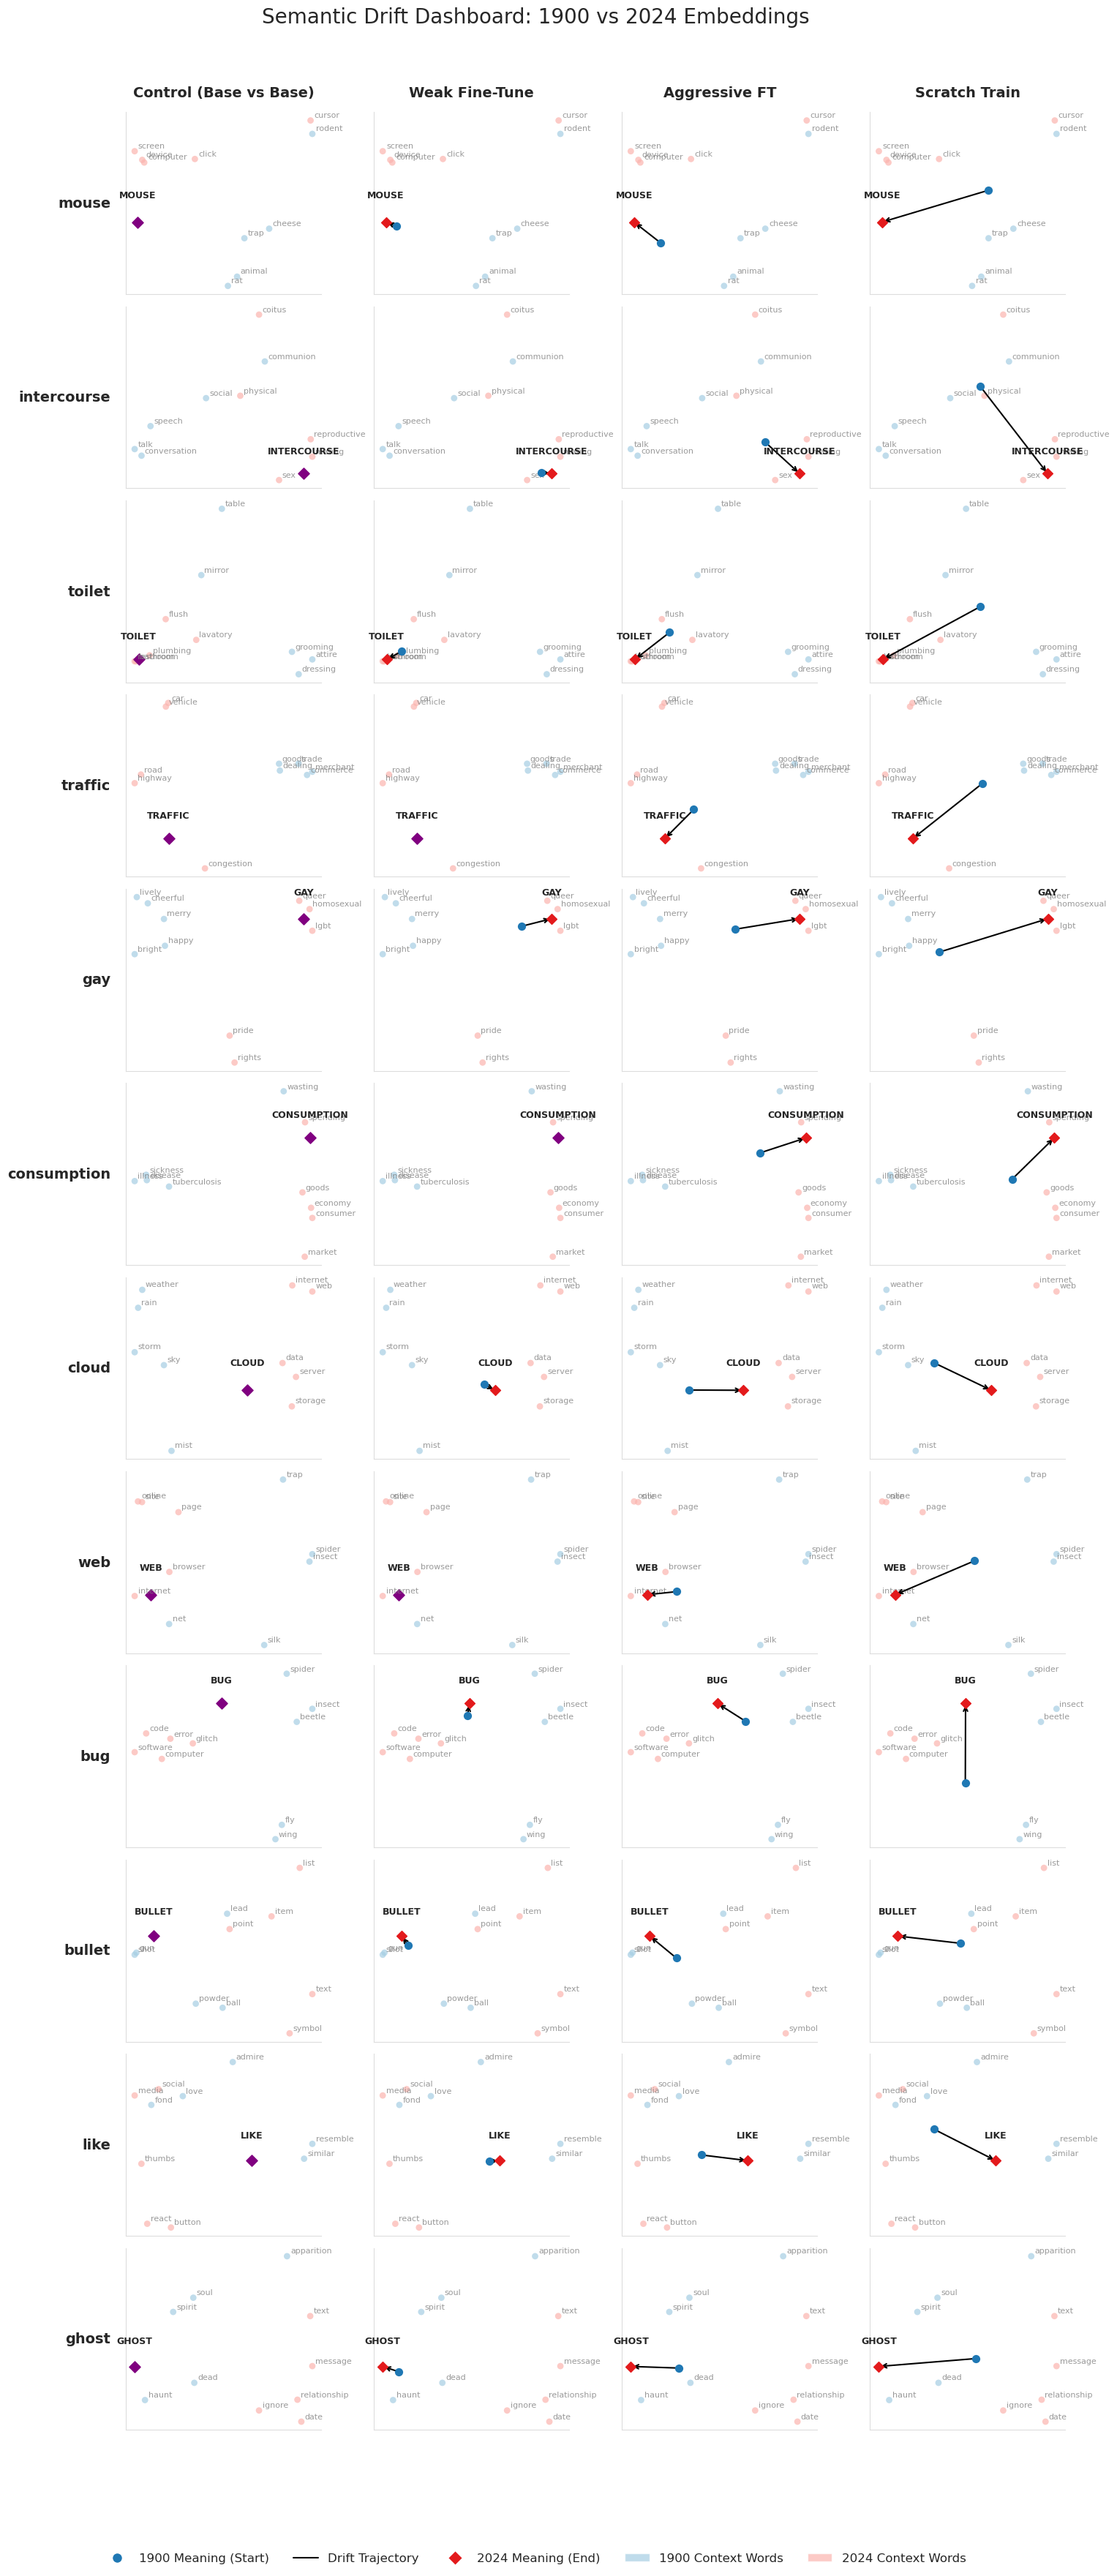

In [19]:
MODEL_PATHS = {
    "BASE": "models/all-MiniLM-L6-v2_static",
    "VARIANTS": {
        "Control (Base vs Base)": "models/all-MiniLM-L6-v2_static",
        "Weak Fine-Tune": "models/pg19_static_final",
        "Aggressive FT": "models/pg19_aggressive_static_final",
        "Scratch Train": "models/pg19_scratch_static_final"
    }
}

WORD_SPECS = {
    "mouse": {
        "old": ["rat", "rodent", "trap", "cheese", "animal"],
        "new": ["click", "computer", "cursor", "screen", "device"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "communion"],
        "new": ["sex", "physical", "reproductive", "mating", "coitus"]
    },
    "toilet": {
        "old": ["dressing", "table", "mirror", "grooming", "attire"],
        "new": ["bathroom", "restroom", "lavatory", "flush", "plumbing"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing"],
        "new": ["car", "road", "highway", "congestion", "vehicle"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively"],
        "new": ["homosexual", "lgbt", "rights", "pride", "queer"]
    },
    "consumption": {
        "old": ["tuberculosis", "disease", "wasting", "illness", "sickness"],
        "new": ["economy", "market", "goods", "spending", "consumer"]
    },
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "weather"],
        "new": ["server", "data", "internet", "web", "storage"]
    },
    "web": {
        "old": ["spider", "net", "trap", "silk", "insect"],
        "new": ["internet", "site", "online", "page", "browser"]
    },
    "bug": {
        "old": ["insect", "fly", "beetle", "spider", "wing"],
        "new": ["software", "code", "error", "glitch", "computer"]
    },
    "bullet": {
        "old": ["shot", "gun", "lead", "powder", "ball"],
        "new": ["point", "list", "item", "symbol", "text"]
    },
    "like": {
        "old": ["similar", "resemble", "love", "admire", "fond"],
        "new": ["social", "media", "button", "react", "thumbs"]
    },
    "ghost": {
        "old": ["spirit", "soul", "apparition", "haunt", "dead"],
        "new": ["ignore", "date", "text", "message", "relationship"]
    }
}

def get_robust_anchors(mod1, mod2, top_n=2000):
    v1 = set(mod1.tokenizer.get_vocab().keys())
    v2 = set(mod2.tokenizer.get_vocab().keys())
    common = sorted(list(v1 & v2))
    anchors = [w for w in common if w.isalpha() and len(w) > 2]
    return anchors[:top_n]

def load_and_align_models(path_base, path_variant):
    try:
        mod_base = StaticModel.from_pretrained(path_base)
        mod_var = StaticModel.from_pretrained(path_variant)
    except Exception:
        return None, None, None, None, None

    anchors = get_robust_anchors(mod_base, mod_var)
    
    A = mod_base.encode(anchors)
    B = mod_var.encode(anchors)
    
    A_mean = A.mean(axis=0, keepdims=True)
    B_mean = B.mean(axis=0, keepdims=True)
    
    A_c = A - A_mean
    B_c = B - B_mean

    R, _ = orthogonal_procrustes(B_c, A_c)
    
    return mod_base, mod_var, R, A_mean, B_mean

def plot_single_subplot(ax, mod_base, mod_var, R, A_mean, B_mean, target_word, specs):
    C_OLD_CTX = '#A6CEE3'
    C_NEW_CTX = '#FBB4AE'
    C_START = '#1F78B4'
    C_END = '#E31A1C'

    old_ctx_words = specs["old"]
    new_ctx_words = specs["new"]
    all_words = list(set(old_ctx_words + new_ctx_words + [target_word]))
    
    try:
        base_vecs = mod_base.encode(all_words)
    except:
        return

    if len(base_vecs) < 2:
        return

    pca = PCA(n_components=2)
    pca_coords_base = pca.fit_transform(base_vecs)
    w2i = {w: i for i, w in enumerate(all_words)}

    def plot_bg(word_list, color):
        for w in word_list:
            if w in w2i:
                idx = w2i[w]
                x, y = pca_coords_base[idx]
                ax.scatter(x, y, c=color, s=40, alpha=0.7, edgecolors='none')
                ax.text(x+0.02, y+0.02, w, fontsize=8, alpha=0.8, color='gray')
    
    plot_bg(old_ctx_words, C_OLD_CTX)
    plot_bg(new_ctx_words, C_NEW_CTX)

    p_end = pca_coords_base[w2i[target_word]]

    v_raw = mod_var.encode([target_word])
    v_aligned = (v_raw - B_mean) @ R + A_mean
    p_start = pca.transform(v_aligned)[0]

    dist = np.linalg.norm(p_end - p_start)
    is_stable = dist < 0.05 

    if is_stable:
        ax.scatter(p_end[0], p_end[1], c='purple', marker='D', s=60)
    else:
        ax.annotate("", xy=p_end, xytext=p_start, 
                   arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
        ax.scatter(p_start[0], p_start[1], c=C_START, marker='o', s=50, zorder=5)
        ax.scatter(p_end[0], p_end[1], c=C_END, marker='D', s=50, zorder=5)

    ax.text(p_end[0], p_end[1] + 0.15, target_word.upper(), 
            ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

def generate_dashboard():
    sns.set_style("white")
    
    rows = list(WORD_SPECS.keys())
    cols = list(MODEL_PATHS["VARIANTS"].keys())
    n_rows, n_cols = len(rows), len(cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    fig.suptitle("Semantic Drift Dashboard: 1900 vs 2024 Embeddings", fontsize=20, y=0.98)
    
    for j, variant_name in enumerate(cols):
        variant_path = MODEL_PATHS["VARIANTS"][variant_name]
        mod_base, mod_var, R, A_mean, B_mean = load_and_align_models(MODEL_PATHS["BASE"], variant_path)
        
        if mod_base is None:
            continue

        for i, word in enumerate(rows):
            if n_rows == 1 and n_cols == 1:
                ax = axes
            elif n_rows == 1:
                ax = axes[j]
            elif n_cols == 1:
                ax = axes[i]
            else:
                ax = axes[i, j]
            
            if i == 0:
                ax.set_title(variant_name, fontsize=14, fontweight='bold', pad=15)
            if j == 0:
                ax.set_ylabel(word, fontsize=14, fontweight='bold', rotation=0, ha='right', va='center', labelpad=15)
            
            plot_single_subplot(ax, mod_base, mod_var, R, A_mean, B_mean, word, WORD_SPECS[word])

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#1F78B4', markersize=10, label='1900 Meaning (Start)'),
        Line2D([0], [0], color='black', lw=1.5, label='Drift Trajectory'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#E31A1C', markersize=10, label='2024 Meaning (End)'),
        Patch(facecolor='#A6CEE3', alpha=0.7, label='1900 Context Words'),
        Patch(facecolor='#FBB4AE', alpha=0.7, label='2024 Context Words'),
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.005))

    plt.tight_layout()
    plt.subplots_adjust(top=0.94, left=0.15, bottom=0.06)
    plt.show()

if __name__ == "__main__":
    generate_dashboard()